# Diabetes Prediction using Logistic Regression
### Machine Learning Project

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

In [3]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Outcome Distribution

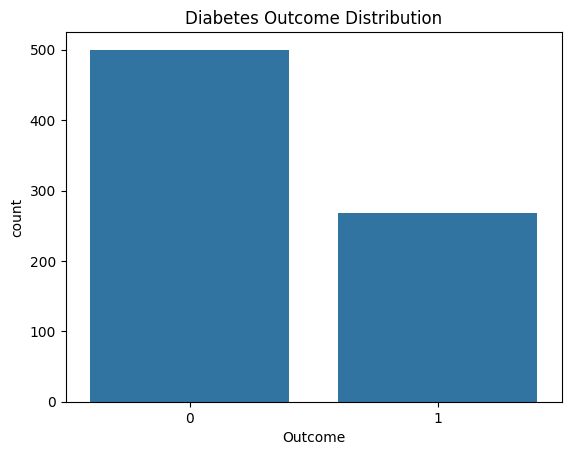

In [20]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

## Handling missing Value

In [4]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

In [5]:
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

## Correlation Heatmap


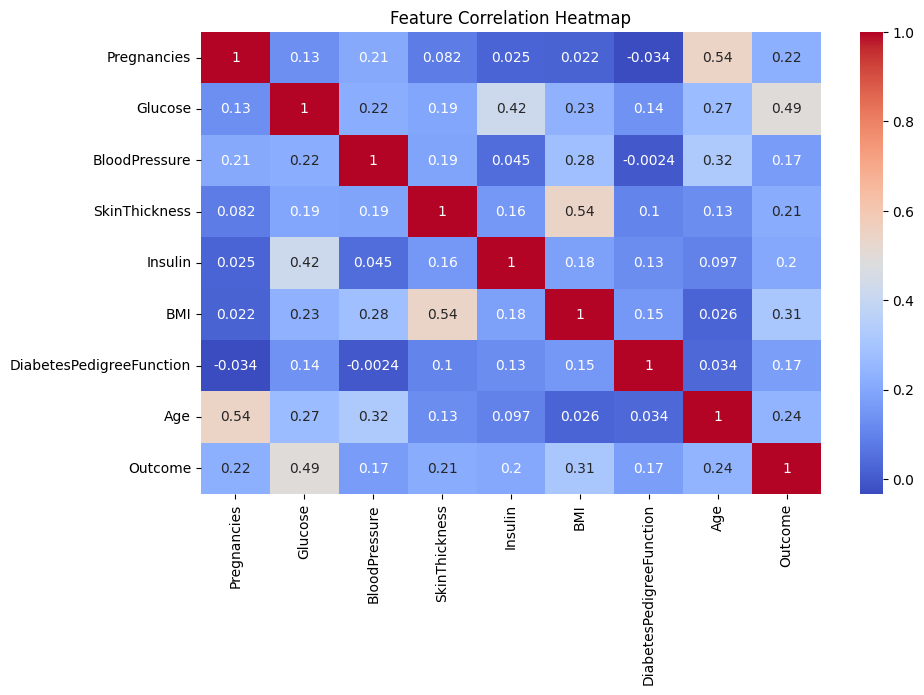

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Glucose vs BMI Scatter Plot


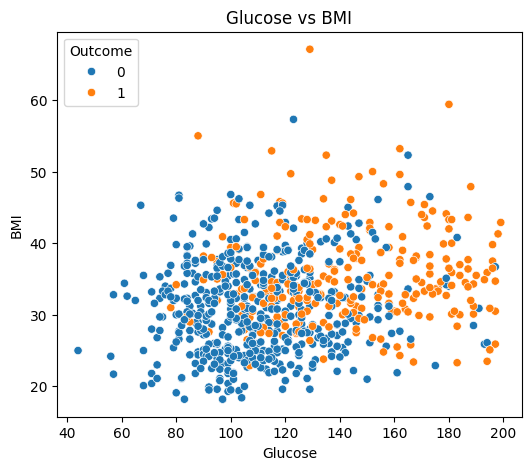

In [22]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Glucose"], y=df["BMI"], hue=df["Outcome"])
plt.title("Glucose vs BMI")
plt.show()

## Feature Scaling

In [6]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

## Train-Test Split

In [7]:
np.random.seed(42)

indices = np.arange(X.shape[0])
np.random.shuffle(indices)

split_ratio = 0.8
split_index = int(split_ratio * len(indices))

train_idx = indices[:split_index]
test_idx = indices[split_index:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

## Logistic Regression

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [9]:
weights = np.zeros(X_train.shape[1])
bias = 0
learning_rate = 0.01
epochs = 1000

In [10]:
for _ in range(epochs):
    
    linear_model = np.dot(X_train, weights) + bias
    y_predicted = sigmoid(linear_model)
    
    # gradients
    dw = (1/len(y_train)) * np.dot(X_train.T, (y_predicted - y_train))
    db = (1/len(y_train)) * np.sum(y_predicted - y_train)
    
    # update
    weights -= learning_rate * dw
    bias -= learning_rate * db

## Prediction

In [11]:
linear_test = np.dot(X_test, weights) + bias
y_pred = sigmoid(linear_test)

# Convert probabilities to 0 or 1
y_pred_class = [1 if i > 0.5 else 0 for i in y_pred]

## Prediction Probability Distribution


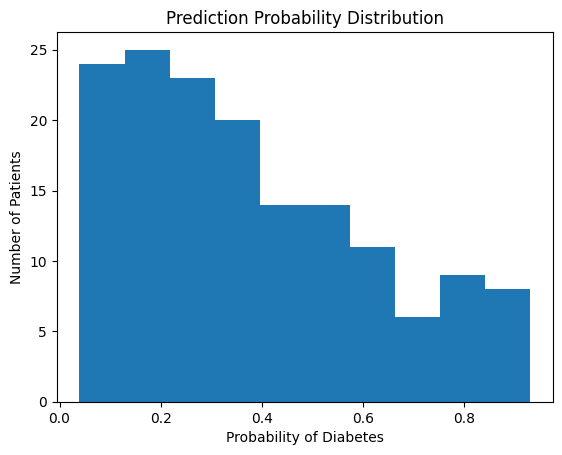

In [23]:
plt.hist(y_pred, bins=10)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Diabetes")
plt.ylabel("Number of Patients")
plt.show()

## Accuracy

In [12]:
correct = np.sum(y_pred_class == y_test)
accuracy = correct / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.7402597402597403


## Confusion Matrix

In [13]:
TP = FP = TN = FN = 0

for i in range(len(y_test)):
    if y_test[i] == 1 and y_pred_class[i] == 1:
        TP += 1
    elif y_test[i] == 0 and y_pred_class[i] == 0:
        TN += 1
    elif y_test[i] == 0 and y_pred_class[i] == 1:
        FP += 1
    elif y_test[i] == 1 and y_pred_class[i] == 0:
        FN += 1

print("Confusion Matrix:")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

Confusion Matrix:
TP: 32
FP: 14
TN: 82
FN: 26


## Confusion Matrix Visualization


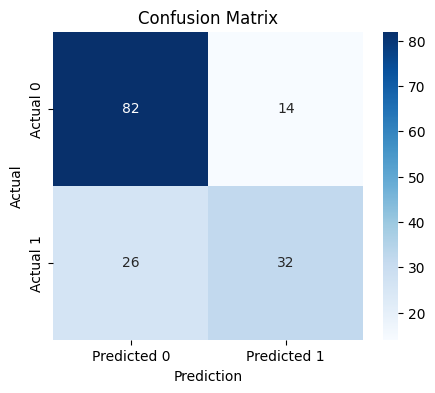

In [24]:
cm = np.array([[TN, FP],
               [FN, TP]])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0","Predicted 1"],
            yticklabels=["Actual 0","Actual 1"])

plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

## Precision

In [14]:
precision = TP / (TP + FP)
print("Precision:", precision)

Precision: 0.6956521739130435


## Recall

In [15]:
recall = TP / (TP + FN)
print("Recall:", recall)

Recall: 0.5517241379310345


## Testing

In [16]:
new_patient = np.array([2,120,70,20,79,25,0.5,33])

In [17]:
new_patient_scaled = (new_patient - mean) / std

In [18]:
linear_value = np.dot(new_patient_scaled, weights) + bias
probability = sigmoid(linear_value)

print("Probability of Diabetes:", probability)

if probability > 0.5:
    print("Prediction: Diabetic")
else:
    print("Prediction: Not Diabetic")

Probability of Diabetes: 0.19618629494484108
Prediction: Not Diabetic


In [19]:
patients = np.array([
    [2,120,70,20,79,25,0.5,33],
    [5,160,90,35,200,32,0.8,45],
    [1,90,60,18,60,22,0.2,25]
])

patients_scaled = (patients - mean) / std

for p in patients_scaled:
    prob = sigmoid(np.dot(p, weights) + bias)
    print("Probability:", prob, 
          "Prediction:", 1 if prob > 0.5 else 0)

Probability: 0.19618629494484108 Prediction: 0
Probability: 0.7340198730245332 Prediction: 1
Probability: 0.05338630002318017 Prediction: 0
